# Cleaning and grounding emerging science concepts: the concept classifier

This notebook is a runnable walk-through of the **concept-cleaning experiment** (artifact `art_BdBvbNuNU8E7`).
The full experiment trains three models and applies them to a frozen frame of 426 candidate "emerging concept" phrases:

1. a **concept / not-concept classifier** (L2 logistic regression on lexical + outcome-blind termhood + PCA(MiniLM) + PCA(SPECTER2) features, trained on D2 silver labels);
2. a **variant merger** (pairwise LR on D3 + MeSH synonym pairs);
3. a **NIL-aware linker** (MiniLM nearest neighbour with a calibrated cosine threshold).

It then freezes the test population for the next iteration.

**What this demo runs:** the headline model, the classifier (pipeline step `s3_classifier`). The code is the artifact's own code, split into cells:
- grouped 5-fold CV tuning on D2-train only;
- thresholds `t_F1` and `t_P90` frozen from out-of-fold probabilities *before* the test set is scored;
- ablations and a gradient-boosting comparison;
- baselines (majority, C-value, the two LLM labellers);
- bootstrap confidence intervals, paired bootstrap differences, a reliability curve and the secondary 3-class model.

**Data:** `mini_demo_data.json` holds a stratified, domain-diverse sample of **100 D2 phrases** (70 train fold, 30 test fold). Each phrase carries the exact feature rows the artifact's `FeatureSource` assembles:
- 45 lexical features;
- 11 termhood statistics computed on arXiv titles up to 2018 plus the D1 corpus;
- a 384-d MiniLM embedding;
- a 768-d SPECTER2 embedding.

The full run used 1,200 train and 300 test phrases. Its headline numbers ship in the data file for comparison (full-run test F1 0.818, AUC 0.888).

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (the artifact logs with loguru)
_pip('loguru==0.7.3')

# numpy, pandas, scikit-learn, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
# --- original imports (src/s3_classifier.py + src/clfdata.py + src/vendor/textnorm.py) ---
from __future__ import annotations

import hashlib
import itertools
import json
import re
import sys
import time
import unicodedata
from collections import Counter

import matplotlib
import numpy as np
import pandas as pd
from loguru import logger
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, balanced_accuracy_score, brier_score_loss, cohen_kappa_score,
                             confusion_matrix, f1_score, roc_auc_score)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# --- notebook additions ---
import matplotlib.pyplot as plt  # inline plots instead of savefig to results/
from pathlib import Path
from threadpoolctl import threadpool_limits

# the matrices here are tiny (70 x 1208); on many-core machines BLAS/OpenMP thread oversubscription makes each
# fit orders of magnitude slower, so cap the native thread pools (no effect on results)
threadpool_limits(4)

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")  # common.setup_logging (stdout sink only)

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-2/experiment-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"{len(data['examples'])} phrases | folds {dict(Counter(e['metadata_fold'] for e in data['examples']))} | "
      f"labels {dict(Counter(e['output'] for e in data['examples']))}")
print(f"{len(data['lex_names'])} lexical, {len(data['th_names'])} termhood, "
      f"{len(data['examples'][0]['minilm'])} MiniLM, {len(data['examples'][0]['specter2'])} SPECTER2 dims per phrase")
pd.DataFrame([{k: e[k] for k in ("key", "output", "metadata_fold", "metadata_macro_domain", "metadata_label_A", "metadata_label_B")}
              for e in data["examples"][:8]])

100-phrase stratified subset of D2 (silver CONCEPT / NOT_CONCEPT / TOO_GENERIC labels; 70 train-fold + 30 test-fold phrases) with the per-phrase feature blocks of the concept classifier: lexical, outcome-blind termhood, MiniLM (384-d) and SPECTER2 (768-d) embeddings.
100 phrases | folds {'train': 70, 'test': 30} | labels {'CONCEPT': 60, 'NOT_CONCEPT': 32, 'TOO_GENERIC': 8}
45 lexical, 11 termhood, 384 MiniLM, 768 SPECTER2 dims per phrase


,key,output,metadata_fold,metadata_macro_domain,metadata_label_A,metadata_label_B
0,routing protocol,CONCEPT,train,computing_engineering,CONCEPT,CONCEPT
1,cronbach alpha value,CONCEPT,train,health,NOT_CONCEPT,CONCEPT
2,drug resistant strain,CONCEPT,train,life,CONCEPT,CONCEPT
3,heterogeneous catalytic oxidation,CONCEPT,train,physical,CONCEPT,CONCEPT
4,critical discourse analysis,CONCEPT,train,social,CONCEPT,CONCEPT
5,orl,CONCEPT,train,computing_engineering,CONCEPT,CONCEPT
6,collateral sesamoidean ligament,CONCEPT,train,health,CONCEPT,CONCEPT
7,glioblastoma multiforme,CONCEPT,train,life,CONCEPT,CONCEPT


## Configuration

All tunable parameters live here. The values in the trailing comments are the artifact's original settings.

Two settings differ from the original because of the 100-phrase demo sample:
- `PCA_GRID` uses 32 components instead of 64. The PCA sees about 56 rows per CV training fold, and PCA cannot have more components than rows.
- `N_BOOT` can be lowered to make the notebook run faster.

In [5]:
# ---- data size (the demo file has 70 train-fold and 30 test-fold phrases; the full run had 1,200 / 300)
MAX_TRAIN = 70            # original: all 1,200 D2-train phrases
MAX_TEST = 30             # original: all 300 D2-test phrases

# ---- primary LR grid (tuned by grouped K-fold CV on train only)
C_GRID = [0.01, 0.03, 0.1, 0.3, 1, 3, 10]   # original: [0.01, 0.03, 0.1, 0.3, 1, 3, 10]
CW_GRID = [None, "balanced"]                 # original: [None, "balanced"]
PCA_GRID = [32, None]                        # original: [64, None]  (64 > rows per CV fold in the 100-phrase demo)
N_SPLITS = 5                                 # original: 5

# ---- HistGradientBoosting comparison grid
HGB_LR = [0.05, 0.1]        # original: [0.05, 0.1]
HGB_LEAVES = [15, 31]       # original: [15, 31]
HGB_L2 = [0.0, 1.0]         # original: [0.0, 1.0]
HGB_MAX_ITER = 300          # original: 300
HGB_PCA = 32                # original: 64

# ---- bootstrap
N_BOOT = 2000               # original: 2000

SEED = 20261001             # original: 20261001 (common.SEED)

## The pipeline (`method.py`)

`method.py` is the artifact's entry point. It runs the step scripts in `src/` in a fixed order, and that order matters. The classifier and its thresholds are frozen, and the frame predictions written, *before* any LLM labels the frame. Only then are merging, linking and the frozen population produced.

The cell below reproduces its step table. This notebook executes **`s3_classifier`** (plus the parts of `clfdata.py`, `featlib.py` and `textnorm.py` that it needs) on the demo sample. The step's inputs come precomputed from `mini_demo_data.json`:
- lexical features (`s2_features`);
- termhood (`s1_corpus`);
- MiniLM and SPECTER2 embeddings (`s2_features` via `encoders.py`).

In [6]:
# verbatim from method.py
STEPS = [("s0_load", []), ("s1a_fetch_arxiv", []), ("s1_corpus", []), ("t1_reused_code", []), ("s2_features", []),
         ("s3_classifier", []), ("s4_merger", []), ("s4b_merger_choice", []), ("s5_link_calib", []), ("s7a_predict", []),
         ("s6_llm_audit", []), ("s7b_merge_link", []), ("s6_llm_audit", ["--links"]), ("s8_freeze", []), ("s9_report", []), ("t3_leakage_checks", [])]

IN_DEMO = {"s1_corpus": "precomputed -> data['examples'][i]['th']", "s2_features": "precomputed -> 'lex', 'minilm', 'specter2'",
           "s3_classifier": "RUN IN THIS NOTEBOOK"}
for i, (name, extra) in enumerate(STEPS):
    print(f"{i:2d}. {name} {' '.join(extra):8s} {IN_DEMO.get(name, '')}")

 0. s0_load          
 1. s1a_fetch_arxiv          
 2. s1_corpus          precomputed -> data['examples'][i]['th']
 3. t1_reused_code          
 4. s2_features          precomputed -> 'lex', 'minilm', 'specter2'
 5. s3_classifier          RUN IN THIS NOTEBOOK
 6. s4_merger          
 7. s4b_merger_choice          
 8. s5_link_calib          
 9. s7a_predict          
10. s6_llm_audit          
11. s7b_merge_link          
12. s6_llm_audit --links  
13. s8_freeze          
14. s9_report          
15. t3_leakage_checks          


## Text normalisation (`src/vendor/textnorm.py`)

`normalise` is the matching key used everywhere in the artifact. It lower-cases, maps Greek letters to names, folds hyphens and slashes, maps British spellings to American, and singularises the head token.

The classifier uses it in two places:
- the **train/test leakage assert**: no normalised key or surface form may occur in both folds;
- `emb_text`: the exact string given to the encoders.

The code below is copied verbatim; only the functions the classifier needs are included.

In [7]:
GREEK = {"α": "alpha", "β": "beta", "γ": "gamma", "δ": "delta", "ε": "epsilon", "ζ": "zeta", "η": "eta",
         "θ": "theta", "κ": "kappa", "λ": "lambda", "μ": "mu", "ν": "nu", "ξ": "xi", "π": "pi", "ρ": "rho",
         "σ": "sigma", "τ": "tau", "φ": "phi", "χ": "chi", "ψ": "psi", "ω": "omega", "Δ": "delta",
         "Γ": "gamma", "Ω": "omega", "Φ": "phi", "Ψ": "psi", "Σ": "sigma", "Λ": "lambda", "Θ": "theta"}
BRIT = {"tumour": "tumor", "behaviour": "behavior", "colour": "color", "haemoglobin": "hemoglobin",
        "anaemia": "anemia", "oestrogen": "estrogen", "paediatric": "pediatric", "optimisation": "optimization",
        "modelling": "modeling", "characterisation": "characterization", "organisation": "organization",
        "localisation": "localization", "stabilisation": "stabilization", "polarisation": "polarization",
        "haemorrhage": "hemorrhage", "leukaemia": "leukemia", "oesophageal": "esophageal", "fibre": "fiber",
        "centre": "center", "aluminium": "aluminum", "sulphur": "sulfur", "sulphate": "sulfate",
        "analyse": "analyze", "ageing": "aging", "labour": "labor", "neighbour": "neighbor",
        "haematopoietic": "hematopoietic", "anaesthesia": "anesthesia", "ischaemic": "ischemic",
        "oedema": "edema", "foetal": "fetal", "caesarean": "cesarean", "programme": "program"}
HYPHEN_RE = re.compile(r"[‐-―−/_]+|-")
SPACE_RE = re.compile(r"\s+")


def plural_to_singular(w: str) -> str:
    '''Tiny rule-based singulariser for the head token (keeps keys deterministic across processes).'''
    if len(w) <= 3 or not w.isalpha():
        return w
    if w.endswith(("ss", "us", "is", "ics", "sis", "xis")):
        return w
    if w.endswith("ies") and len(w) > 4:
        return w[:-3] + "y"
    if w.endswith(("ches", "shes", "xes", "zes", "sses")):
        return w[:-2]
    if w.endswith("s") and not w.endswith("ss"):
        return w[:-1]
    return w


def normalise(surface: str) -> str:
    s = unicodedata.normalize("NFKC", surface)
    for g, name in GREEK.items():
        if g in s:
            s = s.replace(g, f" {name} ")
    s = s.lower()
    s = HYPHEN_RE.sub(" ", s)
    s = s.replace("'s ", " ").replace("’s ", " ")
    s = re.sub(r"[\"“”‘’`,;:!?]", " ", s)
    s = SPACE_RE.sub(" ", s).strip()
    toks = [BRIT.get(t, t) for t in s.split(" ") if t]
    if not toks:
        return ""
    toks[-1] = plural_to_singular(toks[-1])
    return " ".join(toks)


def emb_text(s: str) -> str:  # featlib.emb_text
    '''The exact string given to the encoders for a phrase: normalised key (lower case, hyphens as spaces).'''
    return normalise(s) or s.lower().strip()


print([normalise(x) for x in ["Drug-resistant strains", "Tumour β-cells", "IoT devices"]])

['drug resistant strain', 'tumor beta cell', 'iot device']


## Feature assembly (`src/clfdata.py`, `src/featlib.py`)

`FeatureSource.build` turns a list of phrase items into one matrix with four column blocks:

| block | columns | what it measures |
|---|---|---|
| `lex` | 45 | length, stop-word share, POS of the first and last tokens, head position, acronym / digit / Greek flags, word-frequency (Zipf) and a one-hot POS pattern (vocabulary fitted on D2-train only) |
| `th` | 11 | **outcome-blind termhood** from arXiv ≤ 2018 titles + D1: log frequency, C-value, left/right-context entropies, extension shares, `th_missing` |
| `mini` | 384 | MiniLM phrase embedding (L2-normalised) |
| `spec` | 768 | SPECTER2 phrase embedding (base + proximity adapter, CLS pooling) |

`make_pipeline` standard-scales the tabular blocks and reduces each embedding block with PCA (or leaves it at full dimension) before the logistic regression.

**The only change** is where the rows come from. The original `FeatureSource.__init__` reads `cache/lexical.parquet`, `cache/termhood.pkl` and `cache/emb/*.npy`. Here the same rows are read from `data`. `build` and `make_pipeline` are copied unchanged.

In [8]:
TH_NAMES = ["th_log_f", "th_src_ratio", "th_log_df", "th_cvalue", "th_right_entropy", "th_left_entropy",
            "th_share_right_ext_noun", "th_share_left_ext_adj_noun", "th_max_right_ext_share", "th_right_boundary_share",
            "th_missing"]


class EmbStore:
    '''String -> row lookup (original: cache/emb/{name}.npy, float16, L2-normalised). DEMO: rows from mini_demo_data.json.'''

    def __init__(self, name: str) -> None:
        self.name = name
        self.strings = [e["emb_text"] for e in data["examples"]]          # original: {name}_strings.json
        self.idx = {s: i for i, s in enumerate(self.strings)}
        self.mat = np.asarray([e[name] for e in data["examples"]], dtype=np.float16)  # original: np.load({name}.npy)
        self.extra: dict[str, np.ndarray] = {}

    def get(self, strings: list[str]) -> np.ndarray:
        miss = [s for s in strings if s not in self.idx and s not in self.extra]
        if miss:
            raise KeyError(f"{self.name}: {len(miss)} strings not embedded, e.g. {miss[:3]}")
        return np.stack([self.mat[self.idx[s]].astype(np.float32) if s in self.idx else self.extra[s] for s in strings]) \
            if strings else np.zeros((0, self.mat.shape[1]), dtype=np.float32)

    def has(self, s: str) -> bool:
        return s in self.idx or s in self.extra


class FeatureSource:
    def __init__(self, with_ctx: bool = True) -> None:
        # original: self.lex = pd.read_parquet(WORK / "lexical.parquet"); names from lexical_meta.json
        self.lex_names = data["lex_names"]
        self.lex_idx = {("d2", e["key"]): i for i, e in enumerate(data["examples"])}
        self.lexM = np.asarray([e["lex"] for e in data["examples"]], dtype=np.float32)
        # original: th = pickle.load(open(WORK / "termhood.pkl", "rb")); self.th = th["features"]
        self.th = {f"d2:{e['key']}": dict(zip(data["th_names"], e["th"])) for e in data["examples"] if e["th"] is not None}
        self.mini = EmbStore("minilm")
        self.spec = EmbStore("specter2")
        self.ctx = None  # the context-embedding store (minilm_ctx, 'full_plus_context' ablation) is not shipped in the demo

    def build(self, items: list[dict]) -> tuple[np.ndarray, dict[str, list[int]], list[str]]:
        '''items: {ns, id, th_qid, text, ctx_key}. Returns X, block -> column indices, column names.'''
        L = np.stack([self.lexM[self.lex_idx[(it["ns"], it["id"])]] for it in items])
        T = np.array([[self.th.get(it["th_qid"], {}).get(n, 0.0) if it["th_qid"] in self.th else (1.0 if n == "th_missing" else 0.0)
                       for n in TH_NAMES] for it in items], dtype=np.float32)
        texts = [emb_text(it["text"]) for it in items]
        M = self.mini.get(texts)
        S = self.spec.get(texts)
        blocks_arr = [L, T, M, S]
        names = list(self.lex_names) + TH_NAMES + [f"mini_{i}" for i in range(M.shape[1])] + [f"spec_{i}" for i in range(S.shape[1])]
        if self.ctx is not None:
            C = np.zeros((len(items), M.shape[1]), dtype=np.float32)
            flag = np.zeros((len(items), 1), dtype=np.float32)
            for i, it in enumerate(items):
                cs = self.ctx_map.get(it.get("ctx_key") or "", [])
                if cs:
                    C[i] = self.ctx.get(cs).mean(0)
                else:
                    C[i] = M[i]
                    flag[i] = 1.0
            blocks_arr += [C, flag]
            names += [f"ctx_{i}" for i in range(C.shape[1])] + ["ctx_missing"]
        X = np.concatenate(blocks_arr, axis=1)
        o = 0
        blocks = {}
        for b, arr in zip(["lex", "th", "mini", "spec", "ctx", "ctxflag"], blocks_arr):
            blocks[b] = list(range(o, o + arr.shape[1]))
            o += arr.shape[1]
        return X, blocks, names


def make_pipeline(blocks: dict[str, list[int]], use: list[str], *, pca: int | None, model: str = "lr", C: float = 1.0,
                  class_weight=None, hgb: dict | None = None, multinomial: bool = False) -> Pipeline:
    tr = []
    tab = [c for b in use if b in ("lex", "th", "ctxflag") for c in blocks[b]]
    if tab:
        tr.append(("tab", StandardScaler(), tab))
    for b in use:
        if b in ("mini", "spec", "ctx"):
            n = pca if pca else None
            if n:
                tr.append((b, Pipeline([("pca", PCA(n_components=n, random_state=SEED)), ("sc", StandardScaler())]), blocks[b]))
            else:
                tr.append((b, StandardScaler(), blocks[b]))
    ct = ColumnTransformer(tr, remainder="drop")
    if model == "lr":
        clf = LogisticRegression(C=C, class_weight=class_weight, max_iter=5000, solver="lbfgs")
    else:
        clf = HistGradientBoostingClassifier(random_state=SEED, **(hgb or {}))
    return Pipeline([("ct", ct), ("clf", clf)])

## Metrics (`src/clfdata.py`)

Every test number is reported as a point estimate with a **95 % bootstrap CI**. All models share the *same* resample indices (`boot_idx`), so the **paired bootstrap** in `paired_diff` gives a CI and a one-sided `p_le_0` for "primary minus comparison".

The two threshold rules are applied to out-of-fold (OOF) training probabilities only:
- `best_f1_threshold` gives `t_F1`, the threshold with the best F1 (MAIN population).
- `precision_threshold(…, 0.90)` gives `t_P90`, the smallest threshold with OOF precision ≥ 0.90 (STRICT population).

The code is copied verbatim; only the default number of bootstrap reps now comes from the config.

In [9]:
def _prf(y: np.ndarray, yhat: np.ndarray) -> tuple[float, float, float]:
    tp = float(((y == 1) & (yhat == 1)).sum())
    fp = float(((y == 0) & (yhat == 1)).sum())
    fn = float(((y == 1) & (yhat == 0)).sum())
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    f = 2 * p * r / (p + r) if p + r else 0.0
    return p, r, f


def point_metrics(y: np.ndarray, p: np.ndarray | None, yhat: np.ndarray) -> dict:
    P, R, F = _prf(y, yhat)
    out = {"n": int(len(y)), "n_pos": int(y.sum()), "precision": P, "recall": R, "f1": F,
           "accuracy": float((y == yhat).mean()), "balanced_accuracy": float(balanced_accuracy_score(y, yhat)),
           "kappa": float(cohen_kappa_score(y, yhat)) if len(set(y)) > 1 or len(set(yhat)) > 1 else 0.0}
    if p is not None and len(set(y)) > 1:
        out["auc"] = float(roc_auc_score(y, p))
        out["auprc"] = float(average_precision_score(y, p))
        out["brier"] = float(brier_score_loss(y, np.clip(p, 0, 1)))
    return out


def boot_idx(n: int, reps: int = N_BOOT, seed: int = SEED) -> np.ndarray:  # original default reps = 2000
    return np.random.default_rng(seed).integers(0, n, size=(reps, n))


def boot_metrics(y: np.ndarray, p: np.ndarray | None, yhat: np.ndarray, idx: np.ndarray | None = None,
                 keys=("precision", "recall", "f1", "accuracy", "auc", "auprc", "brier", "balanced_accuracy", "kappa")) -> dict:
    idx = boot_idx(len(y)) if idx is None else idx
    res: dict[str, list[float]] = {k: [] for k in keys}
    def put(k, v):
        if k in res:
            res[k].append(v)
    for b in idx:
        yb, hb = y[b], yhat[b]
        P, R, F = _prf(yb, hb)
        put("precision", P)
        put("recall", R)
        put("f1", F)
        put("accuracy", float((yb == hb).mean()))
        if len(set(yb)) > 1:
            if "balanced_accuracy" in res:
                put("balanced_accuracy", float(balanced_accuracy_score(yb, hb)))
            if "kappa" in res:
                put("kappa", float(cohen_kappa_score(yb, hb)))
            if p is not None:
                pb = p[b]
                if "auc" in res:
                    put("auc", float(roc_auc_score(yb, pb)))
                if "auprc" in res:
                    put("auprc", float(average_precision_score(yb, pb)))
                if "brier" in res:
                    put("brier", float(brier_score_loss(yb, np.clip(pb, 0, 1))))
    pt = point_metrics(y, p, yhat)
    out = {}
    for k, v in res.items():
        if v and k in pt:
            out[k] = {"point": pt[k], "ci95": [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))]}
    out["n"] = pt["n"]
    out["n_pos"] = pt["n_pos"]
    return out


def paired_diff(y: np.ndarray, pa: np.ndarray, ha: np.ndarray, pb: np.ndarray | None, hb: np.ndarray,
                idx: np.ndarray | None = None) -> dict:
    '''Paired bootstrap of F1 and AUC differences (model a minus model b) on the same resamples.'''
    idx = boot_idx(len(y)) if idx is None else idx
    df1, dauc = [], []
    for b in idx:
        yb = y[b]
        df1.append(_prf(yb, ha[b])[2] - _prf(yb, hb[b])[2])
        if len(set(yb)) > 1 and pb is not None:
            dauc.append(roc_auc_score(yb, pa[b]) - roc_auc_score(yb, pb[b]))
    out = {"f1_diff": {"point": _prf(y, ha)[2] - _prf(y, hb)[2],
                       "ci95": [float(np.percentile(df1, 2.5)), float(np.percentile(df1, 97.5))],
                       "p_le_0": float(np.mean(np.array(df1) <= 0))}}
    if dauc:
        out["auc_diff"] = {"point": float(roc_auc_score(y, pa) - roc_auc_score(y, pb)),
                           "ci95": [float(np.percentile(dauc, 2.5)), float(np.percentile(dauc, 97.5))],
                           "p_le_0": float(np.mean(np.array(dauc) <= 0))}
    return out


def best_f1_threshold(y: np.ndarray, p: np.ndarray) -> tuple[float, float]:
    best = (0.5, -1.0)
    for t in np.unique(np.round(p, 4)):
        f = _prf(y, (p >= t).astype(int))[2]
        if f > best[1]:
            best = (float(t), f)
    return best


def precision_threshold(y: np.ndarray, p: np.ndarray, target: float) -> float | None:
    '''Smallest threshold with precision >= target (on the given out-of-fold scores).'''
    for t in np.sort(np.unique(np.round(p, 4))):
        yh = (p >= t).astype(int)
        if yh.sum() == 0:
            break
        if _prf(y, yh)[0] >= target:
            return float(t)
    return None

## Grouped cross-validation and tuning (`src/s3_classifier.py`)

Tuning uses `StratifiedGroupKFold` on D2-train only. Its groups are the D2 **variant clusters**, so spelling variants of one phrase never sit on both sides of a fold. The primary LR grid is C × class_weight × PCA, and the selection criterion is the mean OOF F1 over the folds at 0.5.

The ablations reuse the same tuning with feature blocks removed. `tune_hgb` tunes a HistGradientBoosting comparison. Grids come from the config cell; the logic is unchanged.

In [10]:
FULL = ["lex", "th", "mini", "spec"]
ABLATIONS = {"no_termhood": ["lex", "mini", "spec"], "no_embeddings": ["lex", "th"], "lexical_only": ["lex"],
             "minilm_only": ["mini"], "specter2_only": ["spec"], "full_plus_context": FULL + ["ctx", "ctxflag"]}


def groups_for(rows: list[dict]) -> np.ndarray:
    g = []
    for i, r in enumerate(rows):
        c = r.get("metadata_variant_cluster")
        g.append(str(c) if c is not None else f"solo_{i}")
    return np.array(g)


FOLDS: dict = {}


def oof_proba(make, X, y, groups, n_splits=N_SPLITS) -> np.ndarray:
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    p = np.zeros(len(y))
    fold = np.zeros(len(y), dtype=int)
    for k, (tr, va) in enumerate(cv.split(X, y, groups)):
        m = make()
        m.fit(X[tr], y[tr])
        p[va] = m.predict_proba(X[va])[:, 1]
        fold[va] = k
    FOLDS["last"] = fold
    return p


def mean_fold_f1(y, p, thr=0.5) -> float:
    fold = FOLDS["last"]
    return float(np.mean([f1_score(y[fold == k], (p[fold == k] >= thr).astype(int)) for k in np.unique(fold)]))


def tune_lr(X, y, groups, blocks, use, grid_pca=PCA_GRID) -> tuple[dict, list[dict], np.ndarray]:
    results = []
    best = None
    for C, cw, pca in itertools.product(C_GRID, CW_GRID, grid_pca):
        if not any(b in ("mini", "spec", "ctx") for b in use) and pca is not None:
            continue
        mk = lambda C=C, cw=cw, pca=pca: make_pipeline(blocks, use, pca=pca, C=C, class_weight=cw)
        p = oof_proba(mk, X, y, groups)
        f1 = mean_fold_f1(y, p)  # selection criterion: mean OOF F1 over the 5 folds (at 0.5)
        r = {"C": C, "class_weight": cw, "pca": pca, "oof_f1_at_0.5": f1, "oof_best_thr_f1": best_f1_threshold(y, p)[1],
             "oof_auc": float(point_metrics(y, p, (p >= 0.5).astype(int)).get("auc", np.nan))}
        results.append(r)
        if best is None or r["oof_f1_at_0.5"] > best[0]["oof_f1_at_0.5"]:
            best = (r, p)
    return best[0], results, best[1]


def tune_hgb(X, y, groups, blocks, use) -> tuple[dict, list[dict], np.ndarray]:
    results, best = [], None
    for lr, leaves, l2 in itertools.product(HGB_LR, HGB_LEAVES, HGB_L2):
        hp = {"learning_rate": lr, "max_leaf_nodes": leaves, "l2_regularization": l2, "max_iter": HGB_MAX_ITER,
              "early_stopping": False}
        mk = lambda hp=hp: make_pipeline(blocks, use, pca=HGB_PCA, model="hgb", hgb=hp)
        p = oof_proba(mk, X, y, groups)
        f1 = mean_fold_f1(y, p)
        r = {**hp, "oof_f1_at_0.5": f1, "oof_best_thr_f1": best_f1_threshold(y, p)[1]}
        results.append(r)
        if best is None or f1 > best[0]["oof_f1_at_0.5"]:
            best = (r, p)
    return best[0], results, best[1]

## Step 3a: train/test split, leakage assert and feature matrices

This follows `main()` of `s3_classifier.py`:
1. Split the D2 rows by their frozen `metadata_fold`, dropping `UNRESOLVED` labels (none are in the demo sample).
2. **Assert that no normalised key or surface form is shared between train and test.**
3. Build the feature matrices. The binary target is `CONCEPT` versus anything else.

The one change: the rows come from `data` instead of `data/d2.json`.

In [11]:
t0 = time.time()
d2 = data["examples"]  # original: d2 = read_json(DATA / "d2.json")
tr_rows = [r for r in d2 if r["metadata_fold"] == "train" and r["output"] != "UNRESOLVED"][:MAX_TRAIN]
te_rows = [r for r in d2 if r["metadata_fold"] == "test" and r["output"] != "UNRESOLVED"][:MAX_TEST]
n_unres = sum(r["output"] == "UNRESOLVED" for r in d2 if r["metadata_fold"] in ("train", "test"))
logger.info(f"train {len(tr_rows)} {Counter(r['output'] for r in tr_rows)}; test {len(te_rows)} "
            f"{Counter(r['output'] for r in te_rows)}; dropped UNRESOLVED {n_unres}")
# leakage assert: no normalised key shared between train and test
k_tr = {normalise(r["key"]) for r in tr_rows} | {normalise(s) for r in tr_rows for s in r["surface_forms"]}
k_te = {normalise(r["key"]) for r in te_rows} | {normalise(s) for r in te_rows for s in r["surface_forms"]}
overlap = k_tr & k_te
assert len(overlap) == 0, f"D2 train/test key overlap: {list(overlap)[:5]}"

fs = FeatureSource()


def items_d2(rows):
    return [{"ns": "d2", "id": r["key"], "th_qid": f"d2:{r['key']}", "text": r["key"], "ctx_key": f"d2:{r['key']}"} for r in rows]


Xtr, blocks, names = fs.build(items_d2(tr_rows))
Xte, _, _ = fs.build(items_d2(te_rows))
ytr = np.array([r["output"] == "CONCEPT" for r in tr_rows], dtype=int)
yte = np.array([r["output"] == "CONCEPT" for r in te_rows], dtype=int)
gtr = groups_for(tr_rows)
logger.info(f"X train {Xtr.shape}, blocks { {k: len(v) for k, v in blocks.items()} }")

21:06:20|INFO   |train 70 Counter({'CONCEPT': 44, 'NOT_CONCEPT': 21, 'TOO_GENERIC': 5}); test 30 Counter({'CONCEPT': 16, 'NOT_CONCEPT': 11, 'TOO_GENERIC': 3}); dropped UNRESOLVED 0


21:06:20|INFO   |X train (70, 1208), blocks {'lex': 45, 'th': 11, 'mini': 384, 'spec': 768}


## Step 3b: tune the PRIMARY classifier and freeze its thresholds

The grid search uses training data only. From the best configuration's OOF probabilities two thresholds are derived:
- `t_F1`: the best-F1 threshold, used for the **MAIN** accepted population.
- `t_P90`: the smallest threshold with OOF precision ≥ 0.90, used for the **STRICT** population. If precision 0.90 is never reached, the max OOF probability is used.

The primary model is then refit on all of D2-train. In the artifact, the model and `thresholds.json` are written to `models/` (and hashed) **before** the test phrases are scored. Here they stay in memory.

In [12]:
best, grid, p_oof = tune_lr(Xtr, ytr, gtr, blocks, FULL)
logger.info(f"PRIMARY best config {best} ({time.time() - t0:.0f}s)")
t_f1, oof_f1 = best_f1_threshold(ytr, p_oof)
t_p90 = precision_threshold(ytr, p_oof, 0.90)
primary = make_pipeline(blocks, FULL, pca=best["pca"], C=best["C"], class_weight=best["class_weight"])
primary.fit(Xtr, ytr)
# (original: joblib.dump(...) -> models/concept_lr.joblib; its sha256 goes into thresholds.json)
thresholds = {"t_F1": t_f1, "oof_f1_at_t_F1": oof_f1, "t_P90": t_p90,
              "t_P90_note": "smallest t with OOF precision >= 0.90" if t_p90 is not None else "precision 0.90 never reached; STRICT uses max OOF prob",
              "config": best, "frozen_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())}
if t_p90 is None:
    thresholds["t_P90"] = float(np.max(p_oof))
logger.info(f"thresholds frozen: {thresholds}")
pd.DataFrame(grid).sort_values("oof_f1_at_0.5", ascending=False).head(8)

21:06:23|INFO   |PRIMARY best config {'C': 10, 'class_weight': None, 'pca': 32, 'oof_f1_at_0.5': 0.8416040100250626, 'oof_best_thr_f1': 0.8282828282828283, 'oof_auc': 0.8487762237762237} (4s)


21:06:23|INFO   |thresholds frozen: {'t_F1': 0.1687, 'oof_f1_at_t_F1': 0.8282828282828283, 't_P90': 0.8919, 't_P90_note': 'smallest t with OOF precision >= 0.90', 'config': {'C': 10, 'class_weight': None, 'pca': 32, 'oof_f1_at_0.5': 0.8416040100250626, 'oof_best_thr_f1': 0.8282828282828283, 'oof_auc': 0.8487762237762237}, 'frozen_utc': '2026-09-29T21:06:23Z'}


,C,class_weight,pca,oof_f1_at_0.5,oof_best_thr_f1,oof_auc
24,10.00,None,32.0,0.841604,0.828283,0.848776
26,10.00,balanced,32.0,0.836842,0.836735,0.854895
8,0.10,None,32.0,0.828739,0.842105,0.847028
12,0.30,None,32.0,0.828739,0.838710,0.853147
16,1.00,None,32.0,0.828739,0.829787,0.853147
20,3.00,None,32.0,0.828739,0.836735,0.854021
6,0.03,balanced,32.0,0.828198,0.838710,0.838287
22,3.00,balanced,32.0,0.823726,0.829787,0.854895


## Step 3c: ablations and the gradient-boosting comparison

Each ablation re-tunes the LR with the same grouped CV on a reduced block set. `HGB` is the gradient-boosting comparison model on all blocks.

The artifact then keeps two sensitivity models for scoring the frame:
- the **no-termhood** model, for the `-termhood` sensitivity column;
- the **best CV comparison model**, the F4 sensitivity column.

`full_plus_context` is skipped automatically, as in the artifact whenever the context store is absent (`fs.ctx is None`).

In [13]:
comp: dict = {}
oofs = {"primary": p_oof}
for name, use in ABLATIONS.items():
    if "ctx" in use and fs.ctx is None:
        continue
    b, _, p = tune_lr(Xtr, ytr, gtr, blocks, use)
    tt, _ = best_f1_threshold(ytr, p)
    m = make_pipeline(blocks, use, pca=b["pca"], C=b["C"], class_weight=b["class_weight"]).fit(Xtr, ytr)
    comp[name] = {"config": b, "t_F1": tt, "model": m, "use": use}
    oofs[name] = p
    logger.info(f"ablation {name}: {b}")
hb, hgrid, hp = tune_hgb(Xtr, ytr, gtr, blocks, FULL)
ht, _ = best_f1_threshold(ytr, hp)
hm = make_pipeline(blocks, FULL, pca=HGB_PCA, model="hgb", hgb={k: hb[k] for k in ("learning_rate", "max_leaf_nodes", "l2_regularization", "max_iter", "early_stopping")}).fit(Xtr, ytr)
comp["hgb"] = {"config": hb, "t_F1": ht, "model": hm, "use": FULL}
oofs["hgb"] = hp
# best CV comparison model (F4 sensitivity column): highest OOF best-threshold F1 among comparisons
cv_scores = {k: best_f1_threshold(ytr, v)[1] for k, v in oofs.items() if k != "primary" and k != "full_plus_context"}
best_comp = max(cv_scores, key=cv_scores.get)
# (original: joblib.dump of concept_lr_notermhood / concept_best_comparison + thresholds_comparisons.json)
logger.info(f"best CV comparison model: {best_comp}; OOF best-threshold F1: { {k: round(v, 3) for k, v in cv_scores.items()} }")

21:06:27|INFO   |ablation no_termhood: {'C': 0.1, 'class_weight': None, 'pca': 32, 'oof_f1_at_0.5': 0.8163575605680868, 'oof_best_thr_f1': 0.8333333333333333, 'oof_auc': 0.8076923076923076}


21:06:28|INFO   |ablation no_embeddings: {'C': 0.03, 'class_weight': None, 'pca': None, 'oof_f1_at_0.5': 0.807756557168322, 'oof_best_thr_f1': 0.823529411764706, 'oof_auc': 0.75}


21:06:28|INFO   |ablation lexical_only: {'C': 0.03, 'class_weight': None, 'pca': None, 'oof_f1_at_0.5': 0.7997113997113997, 'oof_best_thr_f1': 0.8148148148148148, 'oof_auc': 0.7036713286713286}


21:06:30|INFO   |ablation minilm_only: {'C': 0.01, 'class_weight': None, 'pca': 32, 'oof_f1_at_0.5': 0.7706192358366272, 'oof_best_thr_f1': 0.7706422018348624, 'oof_auc': 0.6040209790209791}


21:06:33|INFO   |ablation specter2_only: {'C': 0.01, 'class_weight': 'balanced', 'pca': 32, 'oof_f1_at_0.5': 0.8175438596491228, 'oof_best_thr_f1': 0.8222222222222223, 'oof_auc': 0.7884615384615384}


21:06:40|INFO   |best CV comparison model: no_termhood; OOF best-threshold F1: {'no_termhood': 0.833, 'no_embeddings': 0.824, 'lexical_only': 0.815, 'minilm_only': 0.771, 'specter2_only': 0.822, 'hgb': 0.779}


## Step 3d: baseline tuned on train

The **C-value threshold** baseline is the classic termhood statistic, thresholded at its best train F1. The other baselines need no tuning:
- **majority class**;
- the two LLM labellers **A** (gemini-2.5-flash-lite) and **B** (gpt-4.1-nano).

The LLM baselines are *circular*. The silver labels are A/B consensus, or a Haiku adjudication where A and B disagree, so the LLMs helped write the answer key.

In [14]:
th_idx = names.index("th_cvalue")
cv_tr = Xtr[:, th_idx]
t_cv, _ = best_f1_threshold(ytr, cv_tr)
print(f"C-value threshold (train best F1): {t_cv}")

C-value threshold (train best F1): 0.9496999979019165


## Step 3e: TEST, scored once after everything above is frozen

Everything is scored on the held-out test phrases using one shared set of bootstrap resamples:
- the primary model at `t_F1` (MAIN) and at `t_P90` (STRICT);
- every comparison model;
- every baseline.

Also computed: paired primary-minus-X differences, the reliability curve, per-macro-domain metrics, and agreement on the `silver_gold_200` subset against the adjudicator's own label.

In [15]:
p_te = primary.predict_proba(Xte)[:, 1]
h_te = (p_te >= t_f1).astype(int)
h_te_strict = (p_te >= thresholds["t_P90"]).astype(int)
idx = boot_idx(len(yte))
res: dict = {"n_train": len(ytr), "n_test": len(yte), "train_label_counts": dict(Counter(r["output"] for r in tr_rows)),
             "test_label_counts": dict(Counter(r["output"] for r in te_rows)), "dropped_unresolved": n_unres,
             "train_test_key_overlap": len(overlap), "primary_config": best, "thresholds": thresholds,
             "cv_grid_primary": grid, "hgb_grid": hgrid}
res["test_primary_tF1"] = boot_metrics(yte, p_te, h_te, idx)
res["test_primary_tP90"] = boot_metrics(yte, p_te, h_te_strict, idx)
res["confusion_primary_tF1"] = confusion_matrix(yte, h_te).tolist()
# comparisons
res["test_comparisons"] = {}
for name, c in comp.items():
    pc = c["model"].predict_proba(Xte)[:, 1]
    hc = (pc >= c["t_F1"]).astype(int)
    res["test_comparisons"][name] = {"metrics": boot_metrics(yte, pc, hc, idx), "config": c["config"],
                                     "paired_primary_minus_this": paired_diff(yte, p_te, h_te, pc, hc, idx)}
# baselines
maj = int(ytr.mean() >= 0.5)
base = {"majority_class": (np.full(len(yte), 0.5), np.full(len(yte), maj)),
        "cvalue_threshold": (Xte[:, th_idx], (Xte[:, th_idx] >= t_cv).astype(int)),
        "llm_label_A": (None, np.array([r.get("metadata_label_A") == "CONCEPT" for r in te_rows], dtype=int)),
        "llm_label_B": (None, np.array([r.get("metadata_label_B") == "CONCEPT" for r in te_rows], dtype=int))}
res["test_baselines"] = {}
for name, (pb, hb_) in base.items():
    score = pb if pb is not None else hb_.astype(float)
    m = boot_metrics(yte, score if name != "majority_class" else None, hb_, idx)
    if name == "majority_class":
        m["auc"] = {"point": 0.5, "ci95": [0.5, 0.5]}
    res["test_baselines"][name] = {"metrics": m, "paired_primary_minus_this": paired_diff(yte, p_te, h_te, score, hb_, idx)}
res["test_baselines"]["cvalue_threshold"]["t"] = t_cv
res["baseline_note"] = ("LLM labels A (gemini-2.5-flash-lite) and B (gpt-4.1-nano) helped create the silver labels "
                        "(consensus or haiku adjudication of A!=B), so the A/B baselines are optimistic/circular.")
# reliability curve (original bins = 10; the 30-phrase demo test set uses 5 so the bins are not near-empty)
fr, mp_ = calibration_curve(yte, p_te, n_bins=10 if len(yte) >= 100 else 5, strategy="uniform")
res["reliability_curve"] = {"mean_predicted": mp_.tolist(), "fraction_positive": fr.tolist()}
# per macro-domain + silver_gold_200
res["per_macro_domain"] = {}
for dom in sorted({r.get("metadata_macro_domain") for r in te_rows}, key=str):
    ii = np.array([r.get("metadata_macro_domain") == dom for r in te_rows])
    if ii.sum() >= 5:
        res["per_macro_domain"][str(dom)] = point_metrics(yte[ii], p_te[ii] if len(set(yte[ii])) > 1 else None, h_te[ii])
sg = np.array([bool(r.get("metadata_silver_gold_200")) for r in te_rows])
if sg.sum():
    y_adj = np.array([r.get("metadata_label_adj") == "CONCEPT" for r in te_rows], dtype=int)
    res["silver_gold_200"] = {"vs_final_silver": point_metrics(yte[sg], p_te[sg], h_te[sg]),
                              "vs_adjudicator_label": point_metrics(y_adj[sg], p_te[sg], h_te[sg]),
                              "llmA_vs_adjudicator_label": point_metrics(
                                  y_adj[sg], None, np.array([r.get("metadata_label_A") == "CONCEPT" for r in te_rows], dtype=int)[sg])}
logger.info(f"TEST primary: F1 {res['test_primary_tF1']['f1']} AUC {res['test_primary_tF1'].get('auc')}")

21:08:27|INFO   |TEST primary: F1 {'point': 0.7317073170731707, 'ci95': [0.5555555555555556, 0.8627673796791442]} AUC {'point': 0.625, 'ci95': [0.4044027777777777, 0.8240740740740741]}


## Step 3f: SECONDARY 3-class model

The same feature set and configuration are refit as a class-balanced multinomial LR over `CONCEPT`, `NOT_CONCEPT` and `TOO_GENERIC`. The plan calls this model "4-class", but `VARIANT_OF` has almost no D2 items, so it collapses into three classes.

Not run here are the artifact's other secondary analyses, which need other datasets:
- the model trained on D2-train + D4a-train;
- the human anchors E1/E2 (SemEval-2017 / SciERC).

In [16]:
lab3 = {"CONCEPT": 0, "NOT_CONCEPT": 1, "TOO_GENERIC": 2}
y3tr = np.array([lab3.get(r["output"], 1) for r in tr_rows])
y3te = np.array([lab3.get(r["output"], 1) for r in te_rows])
m3 = make_pipeline(blocks, FULL, pca=best["pca"], C=best["C"], class_weight="balanced").fit(Xtr, y3tr)
pr3 = m3.predict(Xte)
res["secondary_3class"] = {"macro_f1": float(f1_score(y3te, pr3, average="macro")),
                           "per_class_f1": dict(zip(lab3, f1_score(y3te, pr3, average=None, labels=[0, 1, 2]).tolist())),
                           "confusion": confusion_matrix(y3te, pr3, labels=[0, 1, 2]).tolist(), "labels": list(lab3),
                           "note": "the plan names this '4-class'; VARIANT_OF has 2 train items and 0 test items, so 3 classes"}
res["runtime_s"] = time.time() - t0
print(json.dumps(res["secondary_3class"], indent=1))
print(f"step 3 runtime: {res['runtime_s']:.1f}s")

{
 "macro_f1": 0.3509803921568628,
 "per_class_f1": {
  "CONCEPT": 0.7,
  "NOT_CONCEPT": 0.35294117647058826,
  "TOO_GENERIC": 0.0
 },
 "confusion": [
  [
   14,
   2,
   0
  ],
  [
   8,
   3,
   0
  ],
  [
   2,
   1,
   0
  ]
 ],
 "labels": [
  "CONCEPT",
  "NOT_CONCEPT",
  "TOO_GENERIC"
 ],
 "note": "the plan names this '4-class'; VARIANT_OF has 2 train items and 0 test items, so 3 classes"
}
step 3 runtime: 127.6s


## Results

The table lists test F1 and AUC with 95 % bootstrap CIs for the primary classifier, the comparison models and the baselines. The `full run F1` column is the artifact's result on 1,200 train and 300 test phrases.

**Read the demo numbers with care.** With 30 test phrases the CIs are wide, and the ranking can differ from the full run. There, the primary LR beat majority / C-value by about +0.10 F1 and LLM-B by +0.045, and lost to the circular LLM-A by −0.08.

In [17]:
ref = data["reference_full_run"]


def row(name, m, full_f1):
    f, a = m["f1"], m.get("auc")
    return {"model": name, "F1": round(f["point"], 3), "F1 95% CI": f"[{f['ci95'][0]:.2f}, {f['ci95'][1]:.2f}]",
            "AUC": (round(a["point"], 3) if a else None), "precision": round(m["precision"]["point"], 3),
            "recall": round(m["recall"]["point"], 3), "full run F1": (round(full_f1, 3) if full_f1 is not None else None)}


rows = [row("PRIMARY LR @ t_F1", res["test_primary_tF1"], ref["test_primary_tF1"]["f1"]["point"]),
        row("PRIMARY LR @ t_P90 (STRICT)", res["test_primary_tP90"], None)]
rows += [row(k, v["metrics"], ref["test_comparisons_f1"].get(k)) for k, v in res["test_comparisons"].items()]
rows += [row("baseline: " + k, v["metrics"], ref["test_baselines_f1"].get(k)) for k, v in res["test_baselines"].items()]
table = pd.DataFrame(rows)
print(f"demo: {res['n_train']} train / {res['n_test']} test   |   full run: {ref['n_train']} train / {ref['n_test']} test")
print(f"frozen thresholds (demo): t_F1={thresholds['t_F1']:.4f}, t_P90={thresholds['t_P90']:.4f}   "
      f"(full run: t_F1={ref['thresholds']['t_F1']}, t_P90={ref['thresholds']['t_P90']})")
print(f"primary config (demo): {{C: {best['C']}, class_weight: {best['class_weight']}, pca: {best['pca']}}}   "
      f"(full run: C={ref['primary_config']['C']}, class_weight={ref['primary_config']['class_weight']}, pca={ref['primary_config']['pca']})")
print("\nPaired bootstrap, primary minus X (F1):")
for k, v in {**res["test_comparisons"], **res["test_baselines"]}.items():
    d = v["paired_primary_minus_this"]["f1_diff"]
    print(f"  {k:18s} {d['point']:+.3f}  CI [{d['ci95'][0]:+.2f}, {d['ci95'][1]:+.2f}]  p(<=0)={d['p_le_0']:.2f}")
table

demo: 70 train / 30 test   |   full run: 1200 train / 300 test
frozen thresholds (demo): t_F1=0.1687, t_P90=0.8919   (full run: t_F1=0.5073, t_P90=0.6468)
primary config (demo): {C: 10, class_weight: None, pca: 32}   (full run: C=0.01, class_weight=None, pca=64)

Paired bootstrap, primary minus X (F1):
  no_termhood        +0.083  CI [-0.02, +0.22]  p(<=0)=0.08
  no_embeddings      -0.012  CI [-0.09, +0.05]  p(<=0)=0.68
  lexical_only       +0.017  CI [-0.08, +0.12]  p(<=0)=0.40
  minilm_only        +0.065  CI [-0.05, +0.20]  p(<=0)=0.14
  specter2_only      +0.151  CI [-0.02, +0.35]  p(<=0)=0.04
  hgb                +0.081  CI [-0.03, +0.21]  p(<=0)=0.09
  majority_class     +0.036  CI [-0.05, +0.12]  p(<=0)=0.21
  cvalue_threshold   +0.036  CI [-0.05, +0.12]  p(<=0)=0.21
  llm_label_A        -0.143  CI [-0.32, +0.01]  p(<=0)=0.96
  llm_label_B        -0.030  CI [-0.13, +0.06]  p(<=0)=0.75


,model,F1,F1 95% CI,AUC,precision,recall,full run F1
0,PRIMARY LR @ t_F1,0.732,"[0.56, 0.86]",0.625,0.600,0.938,0.818
1,PRIMARY LR @ t_P90 (STRICT),0.516,"[0.26, 0.71]",0.625,0.533,0.500,NaN
2,no_termhood,0.649,"[0.45, 0.81]",0.656,0.571,0.750,0.826
3,no_embeddings,0.744,"[0.57, 0.87]",0.612,0.593,1.000,0.774
4,lexical_only,0.714,"[0.54, 0.85]",0.634,0.577,0.938,0.762
5,minilm_only,0.667,"[0.47, 0.82]",0.723,0.538,0.875,0.779
6,specter2_only,0.581,"[0.34, 0.76]",0.661,0.600,0.562,0.780
7,hgb,0.651,"[0.46, 0.79]",0.549,0.519,0.875,0.815
8,baseline: majority_class,0.696,"[0.54, 0.82]",0.500,0.533,1.000,0.715
9,baseline: cvalue_threshold,0.696,"[0.54, 0.82]",0.558,0.533,1.000,0.716


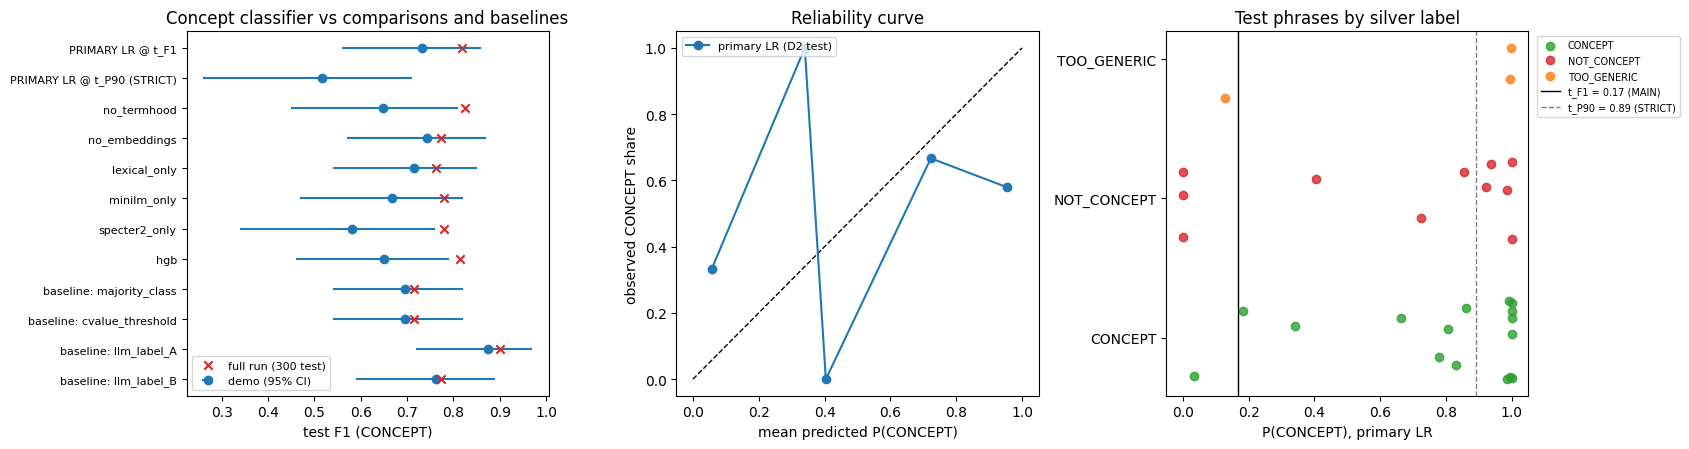

11 / 30 test phrases misclassified at t_F1:


,phrase,silver,p,LLM A,LLM B
0,jute,CONCEPT,0.033,CONCEPT,CONCEPT
1,tracking performance,NOT_CONCEPT,0.921,NOT_CONCEPT,CONCEPT
2,shulman,NOT_CONCEPT,0.725,NOT_CONCEPT,CONCEPT
3,micrometer scale,NOT_CONCEPT,1.000,NOT_CONCEPT,CONCEPT
4,tijekom,NOT_CONCEPT,0.853,NOT_CONCEPT,NOT_CONCEPT
5,practice teaching,NOT_CONCEPT,0.935,NOT_CONCEPT,CONCEPT
6,methods statistical analysis,NOT_CONCEPT,0.985,NOT_CONCEPT,NOT_CONCEPT
7,mc2,NOT_CONCEPT,0.404,NOT_CONCEPT,CONCEPT
8,ideological and political theory course,NOT_CONCEPT,1.000,NOT_CONCEPT,CONCEPT
9,systems design,TOO_GENERIC,0.997,CONCEPT,CONCEPT


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# (1) test F1 with bootstrap CI: demo vs full run
t = table.dropna(subset=["F1"]).reset_index(drop=True)
lo = [float(s.strip("[]").split(",")[0]) for s in t["F1 95% CI"]]
hi = [float(s.strip("[]").split(",")[1]) for s in t["F1 95% CI"]]
yy = np.arange(len(t))
axes[0].errorbar(t["F1"], yy, xerr=[t["F1"] - lo, np.array(hi) - t["F1"]], fmt="o", color="#1f77b4", label="demo (95% CI)")
ff = t["full run F1"].astype(float)
axes[0].scatter(ff, yy, marker="x", color="#d62728", zorder=3, label="full run (300 test)")
axes[0].set_yticks(yy)
axes[0].set_yticklabels(t["model"], fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel("test F1 (CONCEPT)")
axes[0].set_title("Concept classifier vs comparisons and baselines")
axes[0].legend(fontsize=8, loc="lower left")

# (2) reliability curve (original: results/fig_reliability.png)
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].plot(mp_, fr, "o-", color="#1f77b4", label="primary LR (D2 test)")
axes[1].set_xlabel("mean predicted P(CONCEPT)")
axes[1].set_ylabel("observed CONCEPT share")
axes[1].set_title("Reliability curve")
axes[1].legend(loc="upper left", fontsize=8)

# (3) test-set probabilities by silver label, with the two frozen thresholds
for lab, col in (("CONCEPT", "#2ca02c"), ("NOT_CONCEPT", "#d62728"), ("TOO_GENERIC", "#ff7f0e")):
    ii = np.array([r["output"] == lab for r in te_rows])
    axes[2].scatter(p_te[ii], np.random.default_rng(0).uniform(-0.3, 0.3, ii.sum()) + list(lab3).index(lab), color=col, label=lab, alpha=0.8)
axes[2].axvline(thresholds["t_F1"], color="k", lw=1, label=f"t_F1 = {thresholds['t_F1']:.2f} (MAIN)")
axes[2].axvline(thresholds["t_P90"], color="grey", ls="--", lw=1, label=f"t_P90 = {thresholds['t_P90']:.2f} (STRICT)")
axes[2].set_yticks([0, 1, 2])
axes[2].set_yticklabels(list(lab3))
axes[2].set_xlabel("P(CONCEPT), primary LR")
axes[2].set_title("Test phrases by silver label")
axes[2].legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

# test phrases the primary model gets wrong at t_F1
wrong = [{"phrase": r["key"], "silver": r["output"], "p": round(float(p), 3), "LLM A": r["metadata_label_A"], "LLM B": r["metadata_label_B"]}
         for r, y, p, h in zip(te_rows, yte, p_te, h_te) if y != h]
print(f"{len(wrong)} / {len(te_rows)} test phrases misclassified at t_F1:")
pd.DataFrame(wrong)

## What the rest of the artifact does with this model

In the full run, the frozen classifier and thresholds are applied to the 426-concept frame in `s7a_predict`, before any frame LLM label exists. At `t_F1`, 388 of the 426 concepts are accepted. Classifier rejections are enriched for DS1 `sense_check_fail` (Fisher p = 0.025).

The accepted concepts then flow through the rest of the pipeline:
- the **variant merger** (`s4_merger`, pair LR with `p_merge = 0.855`: high precision, low recall);
- the **NIL-aware linker** (`s5_link_calib`, MiniLM with `tau = 0.95`, link precision ≥ 0.90 at NIL prior 0.9, in-KB recall 0.40);
- **freezing** into `results/test_population.json` (`s8_freeze`): MAIN 156, STRICT 147, REFERENCE_ACCEPTED 42, SENSITIVITY 426.

To reproduce the full numbers, run `uv run method.py` in the artifact repository. The demo reproduces the step-3 logic on a 100-phrase sample.